## 01_eda.ipynb

- Первичный анализ данных

In [11]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
root_dir = Path.cwd().parent
print(root_dir)
sys.path.insert(0, str(root_dir))

c:\Users\chise\Desktop\aie_dop\aie_chistyakova\project


In [13]:
from src.utils.configs import load_configs

configs = load_configs()
raw_data_path = configs["data"]["raw_path"]
data_path = root_dir / raw_data_path

df = pd.read_csv(data_path)

print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (300153, 12)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 42.9 MB


In [15]:
print('Пропуски')
print(df.isnull().sum())

Пропуски
Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [16]:
print('Дубликаты')
print(df.duplicated().sum())

Дубликаты
0


In [17]:
print('Cамая большая длительность полета', df['duration'].max())
print('Строк с длительностью полета > 30 часов:', (df['duration'] > 30).sum())

Cамая большая длительность полета 49.83
Строк с длительностью полета > 30 часов: 2226


In [18]:
categorical_cols = ['airline', 'source_city', 'departure_time', 'stops', 
                    'arrival_time', 'destination_city', 'class']
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(col)
    
    print(unique_vals)  

airline
<ArrowStringArray>
['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
Length: 6, dtype: str
source_city
<ArrowStringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str
departure_time
<ArrowStringArray>
['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']
Length: 6, dtype: str
stops
<ArrowStringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str
arrival_time
<ArrowStringArray>
['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']
Length: 6, dtype: str
destination_city
<ArrowStringArray>
['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
Length: 6, dtype: str
class
<ArrowStringArray>
['Economy', 'Business']
Length: 2, dtype: str


In [19]:
df[['duration', 'days_left', 'price']].describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


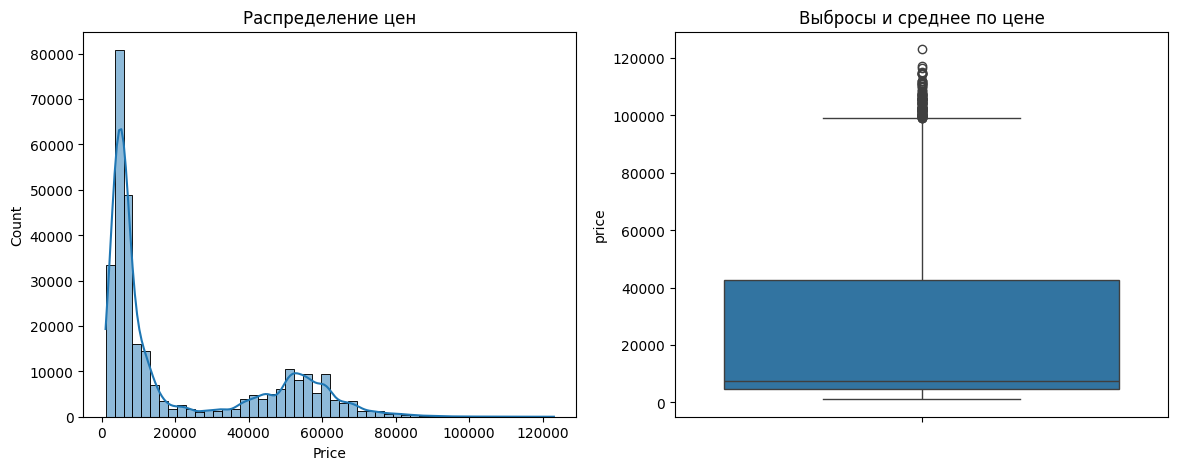

In [21]:
path_target = root_dir / configs['artifacts']['plots']['target_analise']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Распределение цен')
axes[0].set_xlabel('Price')

sns.boxplot(df['price'], ax=axes[1])
axes[1].set_title('Выбросы и среднее по цене')
plt.savefig(path_target)
plt.show()

Несмотря на то, что среднее значение цены составляет около 20 000, видно, что медиана — примерно 7000\8000. Эта разница объясняется наличием двух разных тарифов: бизнес и эконом.

Text(0.5, 1.0, 'Цены в авиакомпаниях по классу обслуживания')

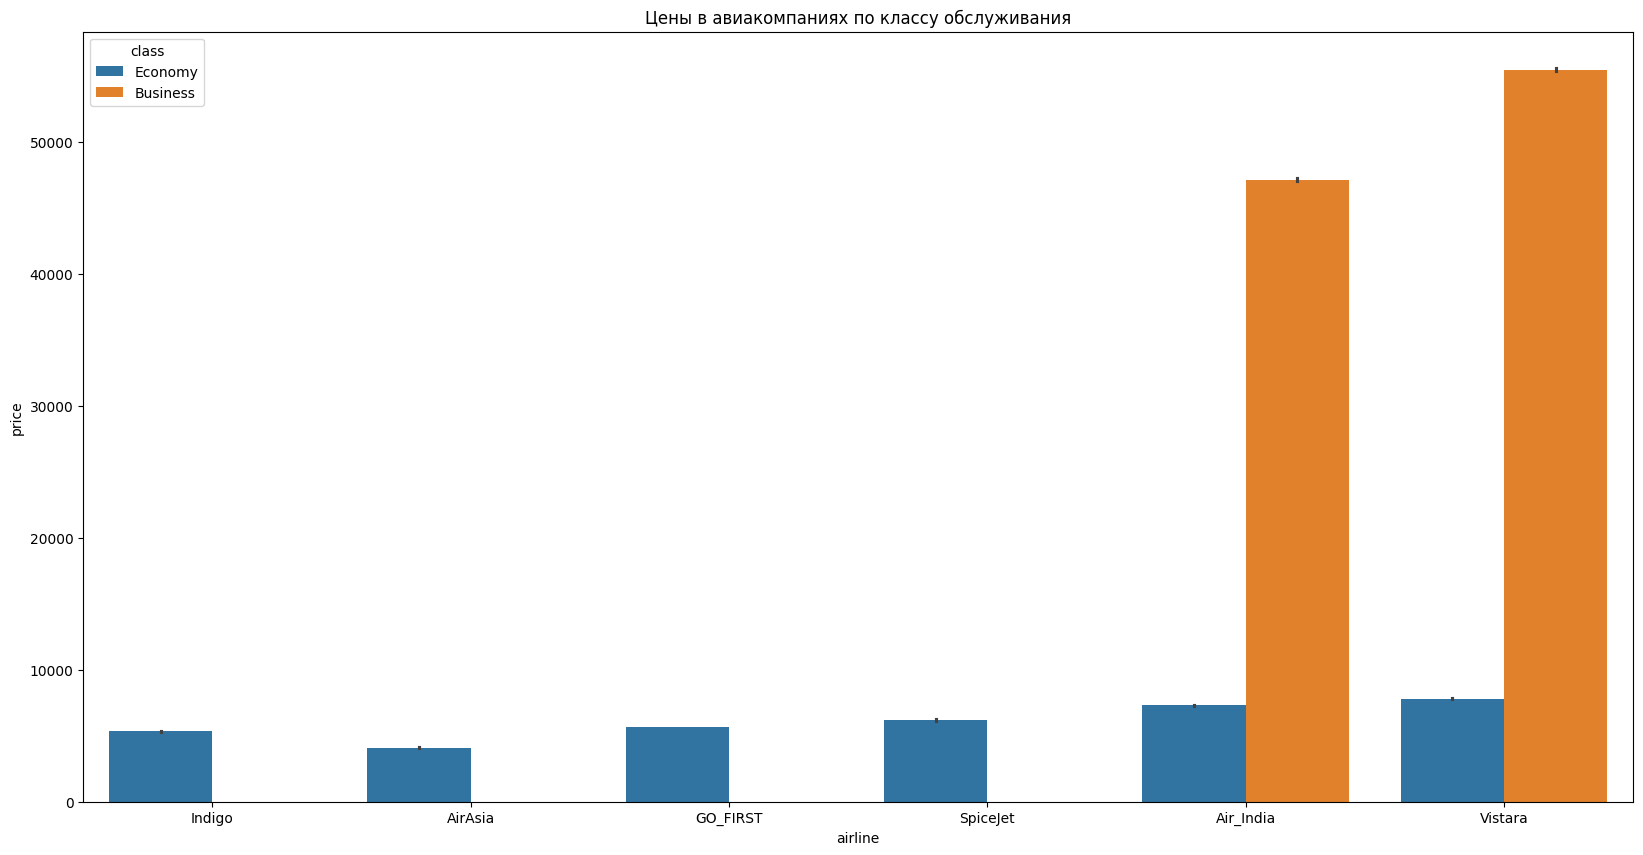

In [47]:
plt.figure(figsize=(20, 10))
sns.barplot(x='airline',y='price',hue="class",data=df.sort_values("price")).set_title('Цены в авиакомпаниях по классу обслуживания')

Бизнес-класс есть только у двух авиакомпаний: Air India и Vistara. Кроме того, разница в ценах на билеты в два этих класса очень велика: стоимость билетов в бизнес-класс почти в пять раз выше, чем в эконом-класс.

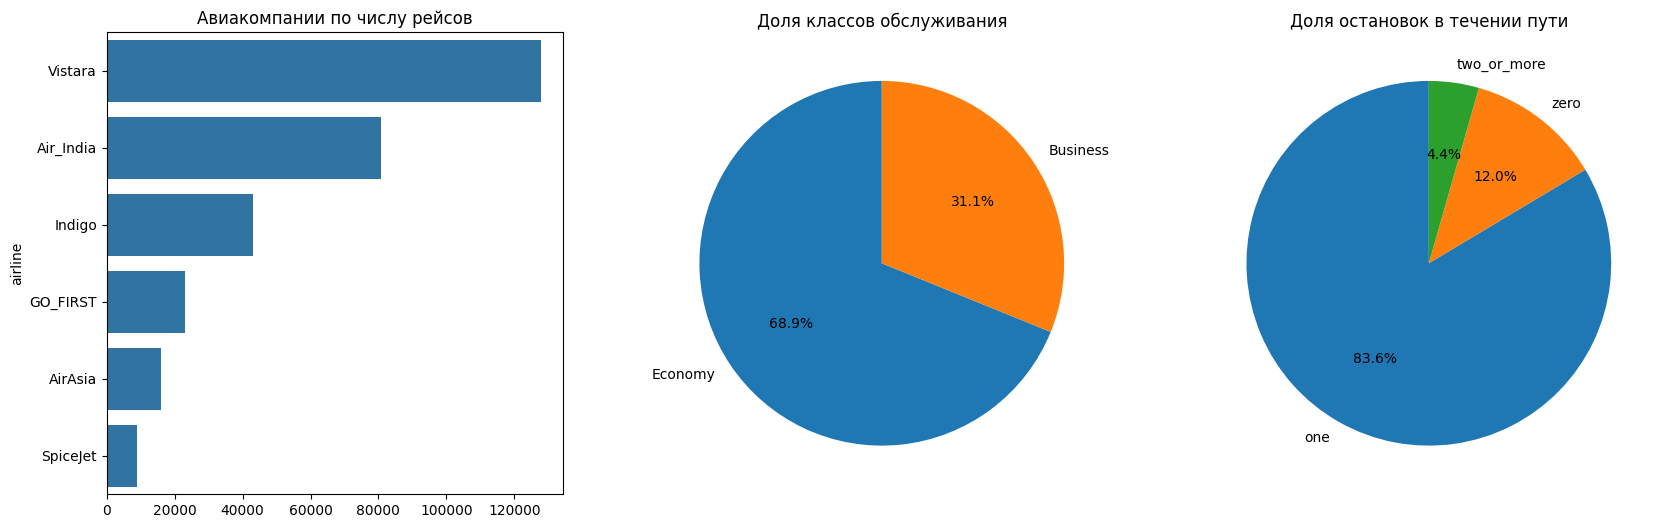

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

airline_counts = df['airline'].value_counts()
sns.barplot(x=airline_counts.values, y=airline_counts.index, ax=axes[0])
axes[0].set_title('Авиакомпании по числу рейсов')

class_counts = df['class'].value_counts()
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Доля классов обслуживания')

stops_counts = df['stops'].value_counts()
axes[2].pie(stops_counts.values, labels=stops_counts.index, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Доля остановок в течении пути')

plt.show()

Text(0.5, 1.0, 'Распределение по городам прибытия')

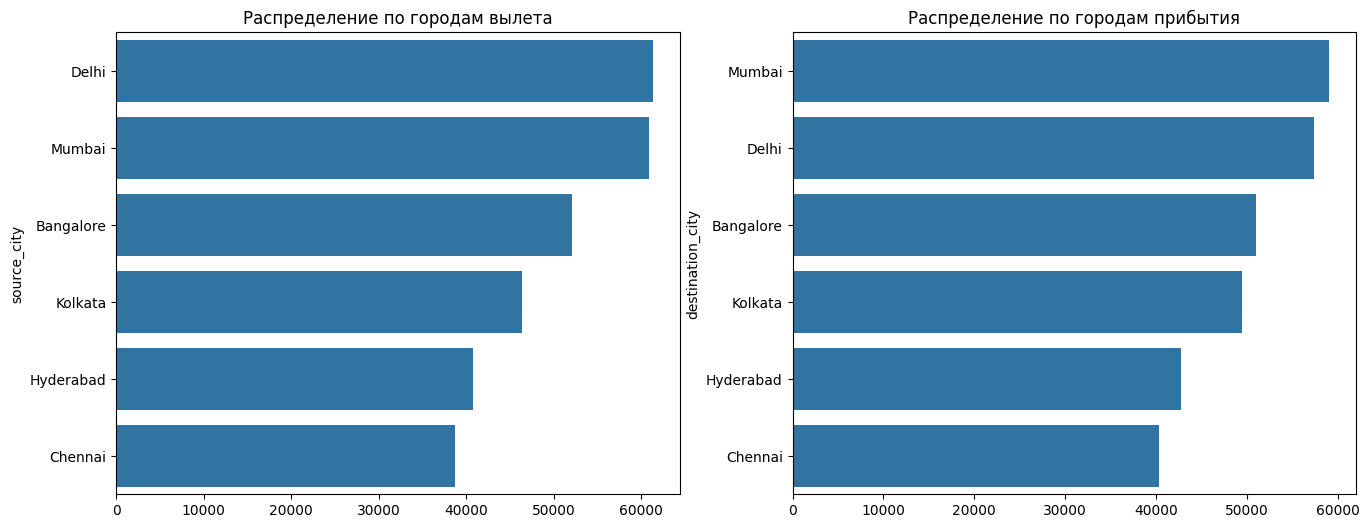

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

source_counts = df['source_city'].value_counts()
sns.barplot(x=source_counts.values, y=source_counts.index, ax=axes[0])
axes[0].set_title('Распределение по городам вылета')

destination_counts = df['destination_city'].value_counts()
sns.barplot(x=destination_counts.values, y=destination_counts.index, ax=axes[1])
axes[1].set_title('Распределение по городам прибытия')

Text(0.5, 1.0, 'Распределение по времени прибытия')

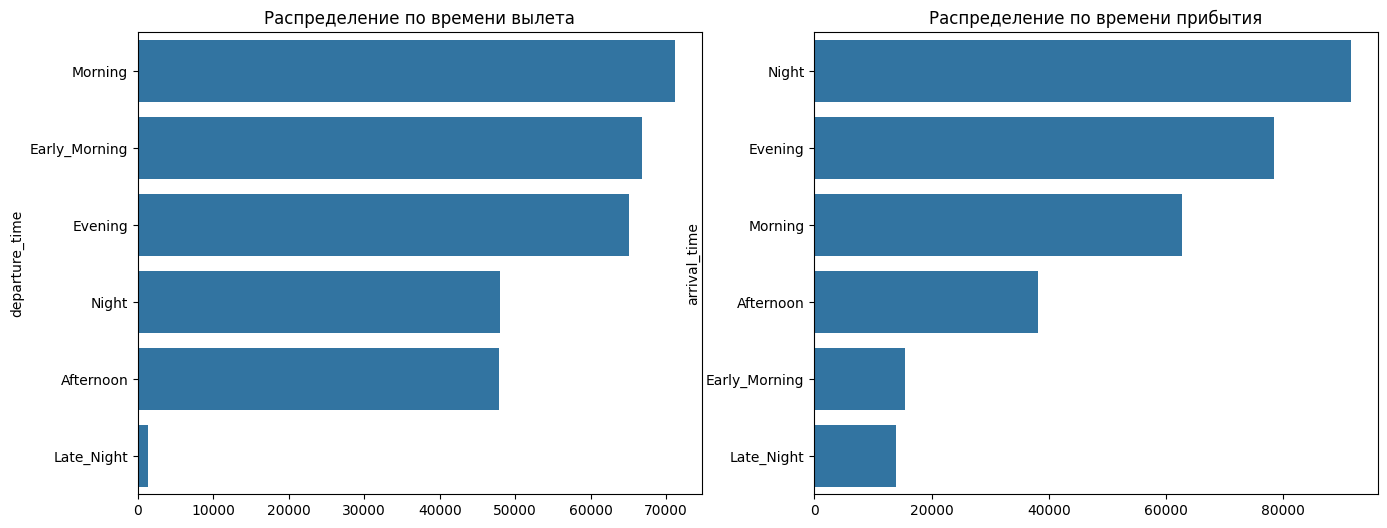

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

departure_counts = df['departure_time'].value_counts()
sns.barplot(x=departure_counts.values, y=departure_counts.index, ax=axes[0])
axes[0].set_title('Распределение по времени вылета')

arrival_counts = df['arrival_time'].value_counts()
sns.barplot(x=arrival_counts.values, y=arrival_counts.index, ax=axes[1])
axes[1].set_title('Распределение по времени прибытия')


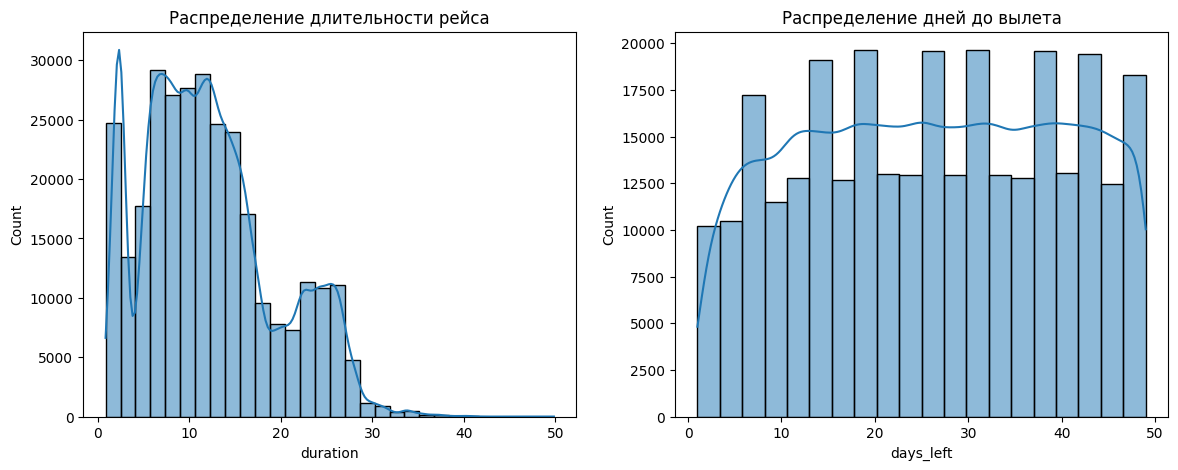

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['duration'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Распределение длительности рейса')

sns.histplot(df['days_left'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Распределение дней до вылета')

plt.show()

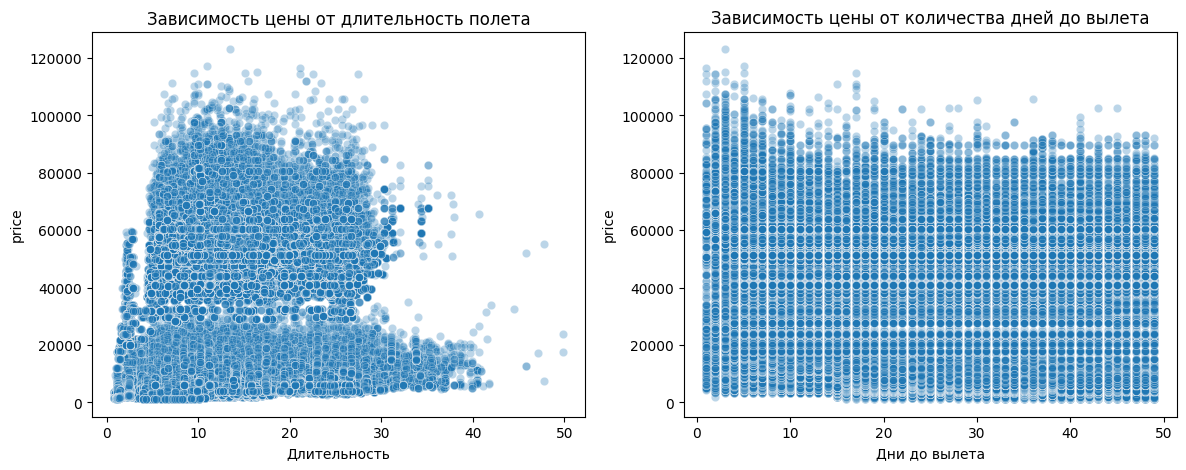

,duration,days_left,price
duration,1.000,-0.039,0.204
days_left,-0.039,1.000,-0.092
price,0.204,-0.092,1.000


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='duration', y='price', data=df, alpha=0.3, ax=axes[0])
axes[0].set_title('Зависимость цены от длительность полета')
axes[0].set_xlabel('Длительность')

sns.scatterplot(x='days_left', y='price', data=df, alpha=0.3, ax=axes[1])
axes[1].set_title('Зависимость цены от количества дней до вылета')
axes[1].set_xlabel('Дни до вылета')
plt.show()

numeric_cols = ['duration', 'days_left', 'price']
corr_matrix = df[numeric_cols].corr()
display(corr_matrix.round(3))

**Вывод**
- Достаточно чистяе данные, отсутствуют пропуски, дубликаты, небольшое количество выбросов
- Основная проблема в категориальных данных и их последующем влиянии или невлиянии на таргет, так как среди числовых нет видимого приоритета